<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

<a name="inicio4"></a>


# **4. Diseño de Experimentos 2026 con R y Python - P4**

## **https://rpubs.com/jseferino/DOEP4**

## **29.** [DCA - COMPARACIÓN DE TRES MÁQUINAS](#T29)

## **30.** [SIMULACIÓN PARA VERIFICAR VALORES ESPERADOS](#T30)

## **31.** [EJEMPLO DCA - COMPARACIÓN DE CUEROS](#T31)

## **32.** [COMPARACIONES MÚLTIPLES - EJEMPLO DE CUEROS](#T32)

## **33.** [EJEMPLO: RESISTENCIA A LA TENSIÓN - DCA - VERIFICACIÓN DE SUPUESTOS](#T33)

## **34.** [PRUEBA DE SHAPIRO-WILK EN R](#T34)

## **35.** [EJEMPLO: MODELO DE EFECTOS ALEATORIOS DURACIÓN DE PRÉSTAMOS HIPOTECARIOS](#T35)


[⬆️ Volver al inicio](#inicio4)

<a name="T29"></a>
## **29. DCA - COMPARACIÓN DE TRES MÁQUINAS**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


[1] "Estadísticos descriptivos:"
# A tibble: 3 × 5
  maquina     n media    sd   var
  <fct>   <int> <dbl> <dbl> <dbl>
1 M1          5  12.2 0.587 0.345
2 M2          5  11.2 0.587 0.345
3 M3          5  10.6 0.771 0.595

ANOVA

Prueba de Tukey HSD
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = tiempo ~ maquina, data = datos)

$maquina
      diff       lwr        upr     p adj
M2-M1 -1.0 -2.104294  0.1042936 0.0774711
M3-M1 -1.6 -2.704294 -0.4957064 0.0058810
M3-M2 -0.6 -1.704294  0.5042936 0.3481597



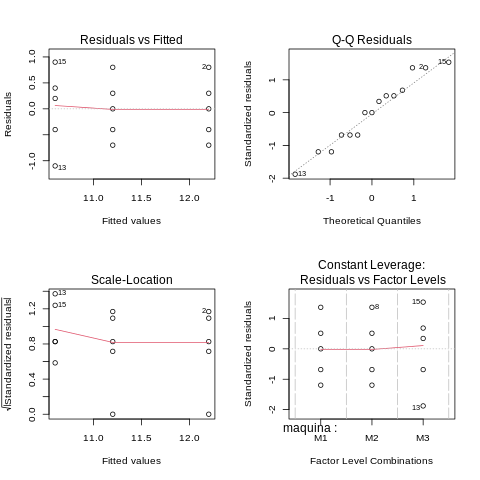

In [ ]:
# ============================================
# @title **B.  DCA - COMPARACIÓN DE TRES MÁQUINAS**
# ============================================
%%R
# Datos
maquina1 <- c(12.5, 13.0, 11.8, 12.2, 11.5)
maquina2 <- c(11.2, 10.5, 12.0, 10.8, 11.5)
maquina3 <- c(10.8, 11.0, 9.5, 10.2, 11.5)

# Crear data frame
datos <- data.frame(
  tiempo = c(maquina1, maquina2, maquina3),
  maquina = factor(rep(c("M1", "M2", "M3"), each = 5))
)

# Estadísticos descriptivos
library(dplyr)
resumen <- datos %>%
  group_by(maquina) %>%
  summarise(
    n = n(),
    media = mean(tiempo),
    sd = sd(tiempo),
    var = var(tiempo),
    .groups = 'drop'
  )
print("Estadísticos descriptivos:")
print(resumen)

# ANOVA
anova_modelo <- aov(tiempo ~ maquina, data = datos)
cat("\n===========================================\n")
cat("ANOVA\n")
cat("===========================================\n")
summary(anova_modelo)

# Gráfico de boxplot
boxplot(tiempo ~ maquina, data = datos,
        col = c("steelblue", "orange", "darkgreen"),
        main = "Comparación de tiempos por máquina",
        xlab = "Máquina", ylab = "Tiempo (segundos)")

# Prueba de Tukey HSD (comparaciones múltiples)
tukey_result <- TukeyHSD(anova_modelo)
cat("\n===========================================\n")
cat("Prueba de Tukey HSD\n")
cat("===========================================\n")
print(tukey_result)

# Gráfico de intervalos de confianza de Tukey
plot(tukey_result, las = 1, col = "steelblue")

# Verificación de supuestos
par(mfrow = c(2, 2))
plot(anova_modelo)

=== ESTADÍSTICOS DESCRIPTIVOS ===
         count  mean       std    var
maquina                              
M1           5  12.2  0.587367  0.345
M2           5  11.2  0.587367  0.345
M3           5  10.6  0.771362  0.595

=== TABLA ANOVA ===
              sum_sq    df         F    PR(>F)
C(maquina)  6.533333   2.0  7.626459  0.007288
Residual    5.140000  12.0       NaN       NaN

Prueba de Levene (homogeneidad de varianzas):
Estadístico: 0.1569, p-valor: 0.8565

=== PRUEBA DE TUKEY HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    M1     M2     -1.0 0.0775 -2.1043  0.1043  False
    M1     M3     -1.6 0.0059 -2.7043 -0.4957   True
    M2     M3     -0.6 0.3482 -1.7043  0.5043  False
----------------------------------------------------


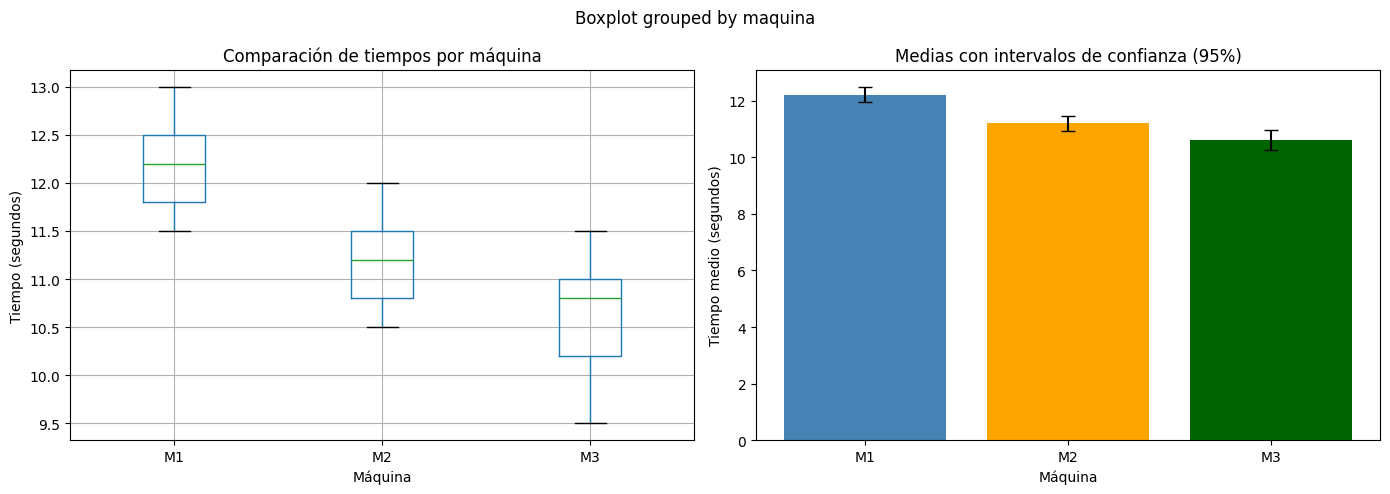

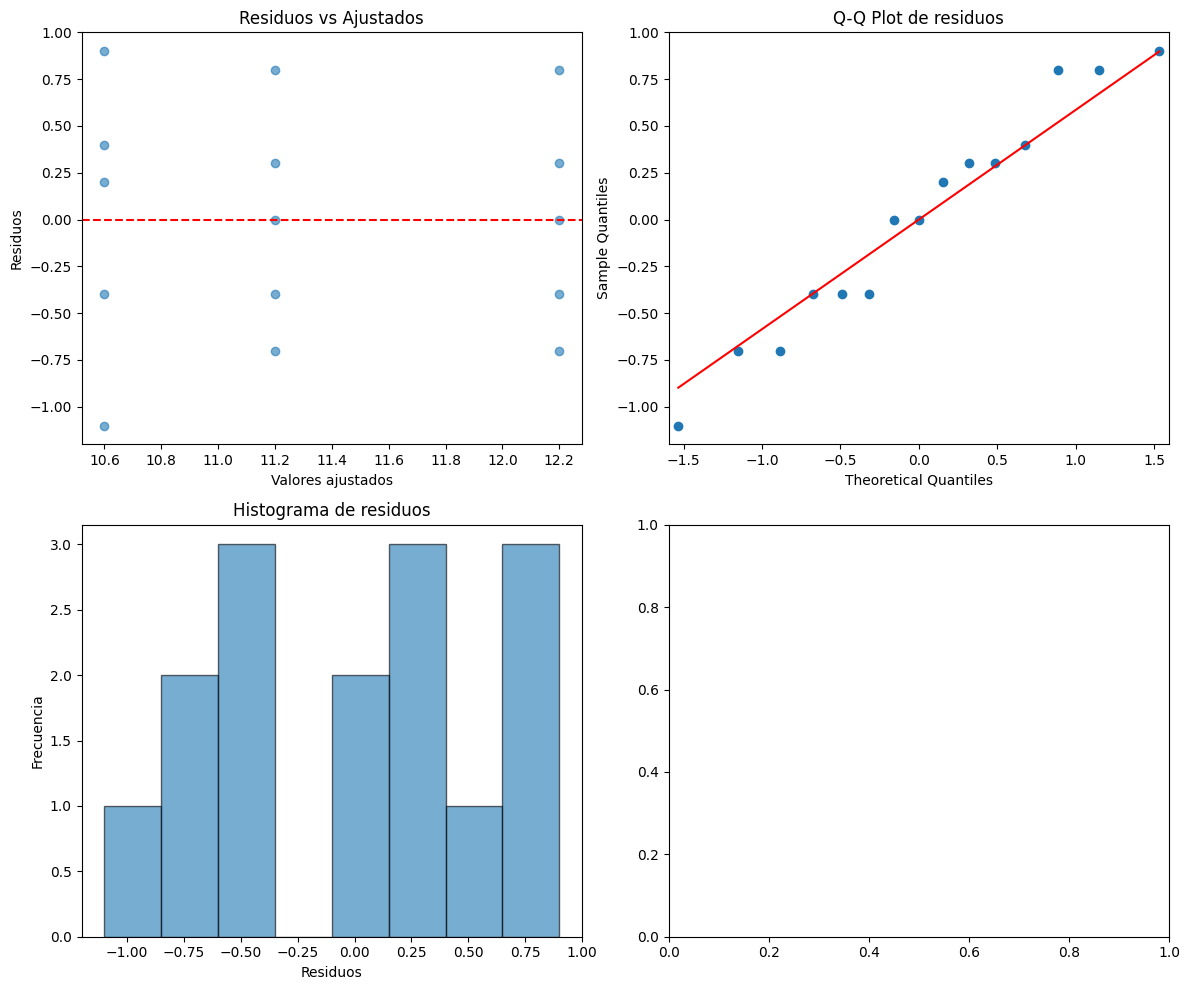

In [ ]:
# ============================================
# @title **C.  EJEMPLO: DCA - COMPARACIÓN DE TRES MÁQUINAS**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Datos
maquina1 = [12.5, 13.0, 11.8, 12.2, 11.5]
maquina2 = [11.2, 10.5, 12.0, 10.8, 11.5]
maquina3 = [10.8, 11.0, 9.5, 10.2, 11.5]

# Crear DataFrame
datos = pd.DataFrame({
    'tiempo': maquina1 + maquina2 + maquina3,
    'maquina': ['M1']*5 + ['M2']*5 + ['M3']*5
})

# Estadísticos descriptivos
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(datos.groupby('maquina')['tiempo'].agg(['count', 'mean', 'std', 'var']))

# ANOVA
modelo = ols('tiempo ~ C(maquina)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("\n=== TABLA ANOVA ===")
print(anova_table)

# Prueba de homogeneidad de varianzas (Levene)
levene_stat, levene_p = levene(maquina1, maquina2, maquina3)
print(f"\nPrueba de Levene (homogeneidad de varianzas):")
print(f"Estadístico: {levene_stat:.4f}, p-valor: {levene_p:.4f}")

# Prueba de Tukey HSD
tukey = pairwise_tukeyhsd(datos['tiempo'], datos['maquina'], alpha=0.05)
print("\n=== PRUEBA DE TUKEY HSD ===")
print(tukey)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
datos.boxplot(column='tiempo', by='maquina', ax=axes[0])
axes[0].set_title('Comparación de tiempos por máquina')
axes[0].set_xlabel('Máquina')
axes[0].set_ylabel('Tiempo (segundos)')

# Gráfico de medias con intervalos de confianza
medias = datos.groupby('maquina')['tiempo'].mean()
errores = datos.groupby('maquina')['tiempo'].sem()
axes[1].bar(medias.index, medias.values, yerr=errores.values,
            color=['steelblue', 'orange', 'darkgreen'], capsize=5)
axes[1].set_title('Medias con intervalos de confianza (95%)')
axes[1].set_xlabel('Máquina')
axes[1].set_ylabel('Tiempo medio (segundos)')

plt.tight_layout()
plt.show()

# Gráfico de residuos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

axes[0, 0].scatter(valores_ajustados, residuos, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados')

sm.qqplot(residuos, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de residuos')

axes[1, 0].hist(residuos, bins=8, edgecolor='black', alpha=0.6)
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de residuos')

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio4)

<a name="T30"></a>
## **30. SIMULACIÓN PARA VERIFICAR VALORES ESPERADOS**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== VERIFICACIÓN DE VALORES ESPERADOS POR SIMULACIÓN ===
Varianza poblacional teórica (σ²): 101.45 
Media de CME simulada: 101.14 
Media de CMTr simulada (H₀): 104.3211 
Valor esperado teórico de CME (σ²): 101.45 
Valor esperado teórico de CMTr (σ²): 101.45 



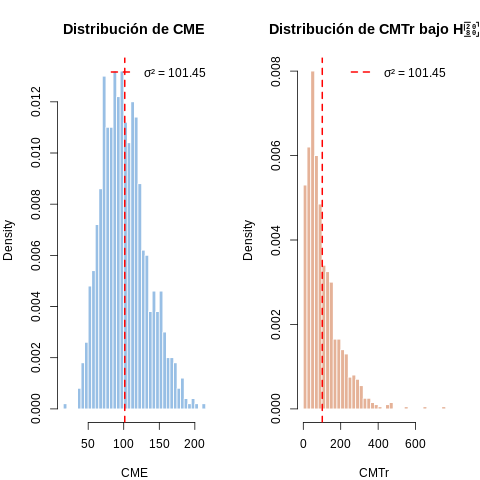

In [ ]:
# ============================================
# @title **B.  SIMULACIÓN PARA VERIFICAR VALORES ESPERADOS**
# ============================================
%%R
set.seed(123)
n_sim <- 1000
k <- 4
n_i <- 6
N <- k * n_i
sigma <- sqrt(101.45)  # CME del ejemplo

# Parámetros bajo H₀ (sin efectos de tratamiento)
tau <- c(0, 0, 0, 0)

# Almacenar resultados
CME_sim <- numeric(n_sim)
CMTr_sim <- numeric(n_sim)

for (sim in 1:n_sim) {
  # Generar datos bajo H₀
  datos <- data.frame()
  for (i in 1:k) {
    y <- rnorm(n_i, mean = 0, sd = sigma)
    datos <- rbind(datos, data.frame(trat = paste0("T", i), y = y))
  }

  # Calcular ANOVA
  anova_res <- aov(y ~ trat, data = datos)
  summary_anova <- summary(anova_res)

  # Extraer cuadrados medios
  CME_sim[sim] <- summary_anova[[1]]$`Mean Sq`[2]
  CMTr_sim[sim] <- summary_anova[[1]]$`Mean Sq`[1]
}

# Resultados
cat("=== VERIFICACIÓN DE VALORES ESPERADOS POR SIMULACIÓN ===\n")
cat("Varianza poblacional teórica (σ²):", sigma^2, "\n")
cat("Media de CME simulada:", round(mean(CME_sim), 4), "\n")
cat("Media de CMTr simulada (H₀):", round(mean(CMTr_sim), 4), "\n")
cat("Valor esperado teórico de CME (σ²):", round(sigma^2, 4), "\n")
cat("Valor esperado teórico de CMTr (σ²):", round(sigma^2, 4), "\n\n")

# Gráficos
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

hist(CME_sim, breaks = 30, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Distribución de CME",
     xlab = "CME")
abline(v = sigma^2, col = "red", lwd = 2, lty = 2)
legend("topright", legend = paste("σ² =", sigma^2),
       col = "red", lty = 2, lwd = 2, bty = "n")

hist(CMTr_sim, breaks = 30, prob = TRUE,
     col = rgb(0.8, 0.4, 0.2, 0.5), border = "white",
     main = "Distribución de CMTr bajo H₀",
     xlab = "CMTr")
abline(v = sigma^2, col = "red", lwd = 2, lty = 2)
legend("topright", legend = paste("σ² =", sigma^2),
       col = "red", lty = 2, lwd = 2, bty = "n")

=== VERIFICACIÓN DE VALORES ESPERADOS POR SIMULACIÓN ===
Varianza poblacional teórica (σ²): 101.4500
Media de CME simulada: 100.6045
Media de CMTr simulada (H₀): 100.0478
Valor esperado teórico de CME (σ²): 101.4500
Valor esperado teórico de CMTr (σ²): 101.4500


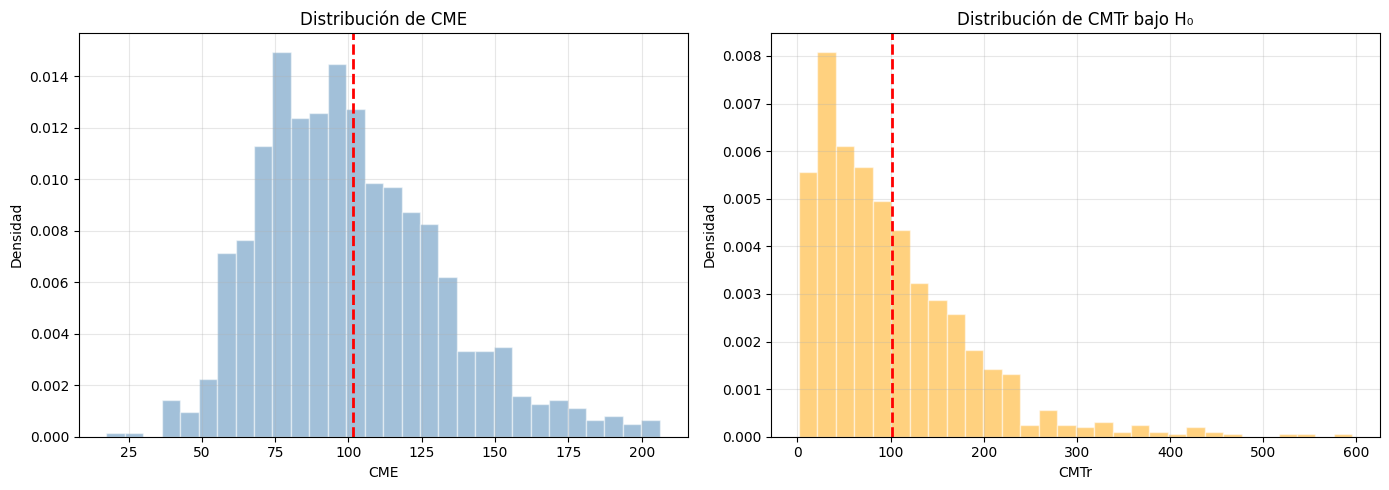

In [ ]:
# ============================================
# @title **C.  SIMULACIÓN PARA VERIFICAR VALORES ESPERADOS**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

np.random.seed(123)
n_sim = 1000
k = 4
n_i = 6
N = k * n_i
sigma = np.sqrt(101.45)  # CME del ejemplo

# Simulación
CME_sim = []
CMTr_sim = []

for _ in range(n_sim):
    datos = []
    for i in range(k):
        y = np.random.normal(0, sigma, n_i)
        datos.extend(y)

    # Convert datos to a NumPy array for proper indexing
    datos = np.array(datos)

    # Crear grupos
    grupos = np.repeat(range(k), n_i)

    # Calcular ANOVA manualmente
    medias_grupo = [np.mean(datos[grupos == i]) for i in range(k)]
    media_total = np.mean(datos)

    # Suma de cuadrados
    SCTr = sum(n_i * (m - media_total)**2 for m in medias_grupo)
    SCT = sum((d - media_total)**2 for d in datos)
    SCE = SCT - SCTr

    # Cuadrados medios
    CMTr = SCTr / (k - 1)
    CME = SCE / (N - k)

    CME_sim.append(CME)
    CMTr_sim.append(CMTr)

# Resultados
print("=== VERIFICACIÓN DE VALORES ESPERADOS POR SIMULACIÓN ===")
print(f"Varianza poblacional teórica (σ²): {sigma**2:.4f}")
print(f"Media de CME simulada: {np.mean(CME_sim):.4f}")
print(f"Media de CMTr simulada (H₀): {np.mean(CMTr_sim):.4f}")
print(f"Valor esperado teórico de CME (σ²): {sigma**2:.4f}")
print(f"Valor esperado teórico de CMTr (σ²): {sigma**2:.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(CME_sim, bins=30, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')
axes[0].axvline(sigma**2, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('CME')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de CME')
axes[0].grid(True, alpha=0.3)

axes[1].hist(CMTr_sim, bins=30, density=True, alpha=0.5,
             color='orange', edgecolor='white')
axes[1].axvline(sigma**2, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('CMTr')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de CMTr bajo H₀')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio4)

<a name="T31"></a>
## **31. EJEMPLO DCA - COMPARACIÓN DE CUEROS**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


[1] "Estadísticos descriptivos:"
  tipo desgaste.n desgaste.media desgaste.sd desgaste.var
1    A   6.000000     256.666667    8.286535    68.666667
2    B   6.000000     210.500000    7.259477    52.700000
3    C   6.000000     230.833333   16.339115   266.966667
4    D   6.000000     220.666667    4.179314    17.466667

ANOVA

Prueba de Bartlett para homogeneidad de varianzas


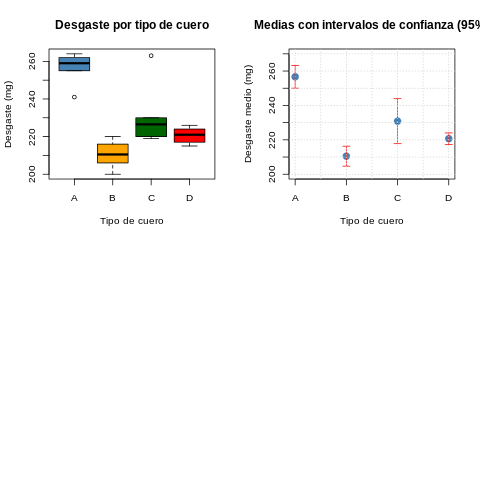

In [ ]:
# ============================================
# @title **B.  EJEMPLO DCA - COMPARACIÓN DE CUEROS (SIN PAQUETES ADICIONALES)**
# ============================================
%%R
# Datos
cuero_A <- c(264, 260, 258, 241, 262, 255)
cuero_B <- c(208, 220, 216, 200, 213, 206)
cuero_C <- c(220, 263, 219, 225, 230, 228)
cuero_D <- c(217, 226, 215, 224, 220, 222)

# Crear data frame
desgaste <- c(cuero_A, cuero_B, cuero_C, cuero_D)
tipo <- factor(rep(c("A", "B", "C", "D"), each = 6))
datos <- data.frame(desgaste, tipo)

# Estadísticos descriptivos (usando R base)
resumen <- aggregate(desgaste ~ tipo, data = datos,
                     FUN = function(x) c(n = length(x),
                                         media = mean(x),
                                         sd = sd(x),
                                         var = var(x)))
print("Estadísticos descriptivos:")
print(resumen)

# ANOVA
anova_modelo <- aov(desgaste ~ tipo, data = datos)
cat("\n===========================================\n")
cat("ANOVA\n")
cat("===========================================\n")
summary(anova_modelo)

# Verificación de supuestos
par(mfrow = c(2, 2))
plot(anova_modelo)

# Prueba de homogeneidad de varianzas (Bartlett - R base)
cat("\n===========================================\n")
cat("Prueba de Bartlett para homogeneidad de varianzas\n")
cat("===========================================\n")
bartlett.test(desgaste ~ tipo, data = datos)

# Gráfico de boxplot
boxplot(desgaste ~ tipo, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red"),
        main = "Desgaste por tipo de cuero",
        xlab = "Tipo de cuero", ylab = "Desgaste (mg)")

# Gráfico de medias con intervalos de confianza
medias <- tapply(desgaste, tipo, mean)
errores <- tapply(desgaste, tipo, function(x) sd(x)/sqrt(length(x)))

plot(1:4, medias, pch = 19, col = "steelblue", cex = 1.5,
     xlab = "Tipo de cuero", ylab = "Desgaste medio (mg)",
     xaxt = "n", ylim = c(200, 270),
     main = "Medias con intervalos de confianza (95%)")
axis(1, at = 1:4, labels = names(medias))
arrows(1:4, medias - 1.96*errores, 1:4, medias + 1.96*errores,
       angle = 90, code = 3, length = 0.05, col = "red")
grid()

=== ESTADÍSTICOS DESCRIPTIVOS ===
      count        mean        std         var
tipo                                          
A         6  256.666667   8.286535   68.666667
B         6  210.500000   7.259477   52.700000
C         6  230.833333  16.339115  266.966667
D         6  220.666667   4.179314   17.466667

=== TABLA ANOVA ===
               sum_sq    df          F    PR(>F)
C(tipo)   7072.333333   3.0  23.237501  0.000001
Residual  2029.000000  20.0        NaN       NaN

Prueba de Levene: estadístico = 0.6655, p-valor = 0.5830


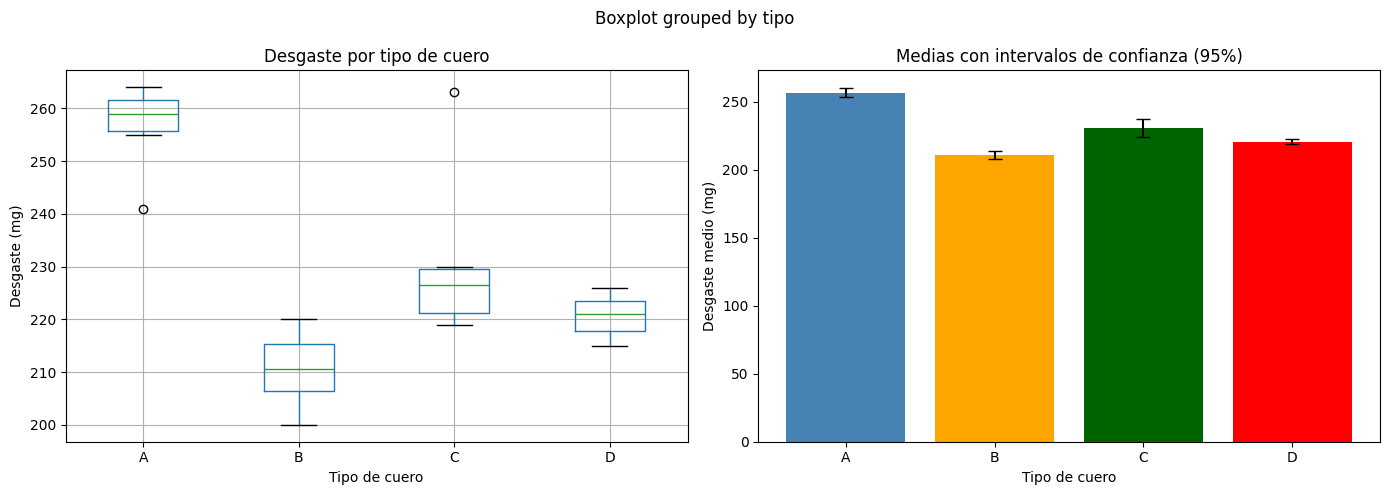

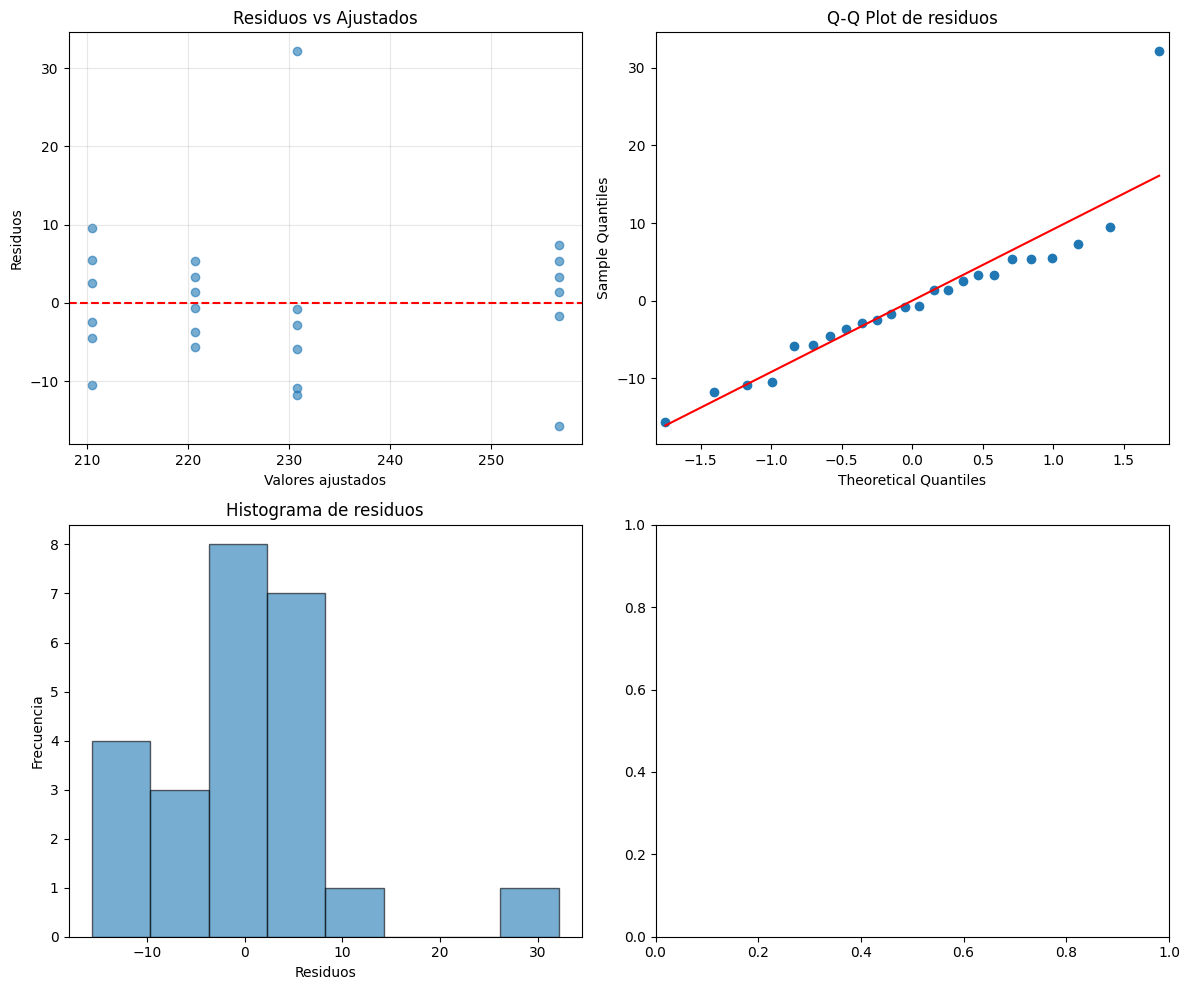

In [ ]:
# ============================================
# @title **C.  EJEMPLO DCA - COMPARACIÓN DE CUEROS**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Datos
cuero_A = [264, 260, 258, 241, 262, 255]
cuero_B = [208, 220, 216, 200, 213, 206]
cuero_C = [220, 263, 219, 225, 230, 228]
cuero_D = [217, 226, 215, 224, 220, 222]

# Crear DataFrame
datos = pd.DataFrame({
    'desgaste': cuero_A + cuero_B + cuero_C + cuero_D,
    'tipo': ['A']*6 + ['B']*6 + ['C']*6 + ['D']*6
})

# Estadísticos descriptivos
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(datos.groupby('tipo')['desgaste'].agg(['count', 'mean', 'std', 'var']))

# ANOVA
modelo = ols('desgaste ~ C(tipo)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("\n=== TABLA ANOVA ===")
print(anova_table)

# Prueba de Levene (homogeneidad de varianzas)
levene_stat, levene_p = levene(cuero_A, cuero_B, cuero_C, cuero_D)
print(f"\nPrueba de Levene: estadístico = {levene_stat:.4f}, p-valor = {levene_p:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
datos.boxplot(column='desgaste', by='tipo', ax=axes[0])
axes[0].set_title('Desgaste por tipo de cuero')
axes[0].set_xlabel('Tipo de cuero')
axes[0].set_ylabel('Desgaste (mg)')

# Gráfico de medias
medias = datos.groupby('tipo')['desgaste'].mean()
errores = datos.groupby('tipo')['desgaste'].sem()
axes[1].bar(medias.index, medias.values, yerr=errores.values,
            color=['steelblue', 'orange', 'darkgreen', 'red'],
            capsize=5)
axes[1].set_title('Medias con intervalos de confianza (95%)')
axes[1].set_xlabel('Tipo de cuero')
axes[1].set_ylabel('Desgaste medio (mg)')

plt.tight_layout()
plt.show()

# Gráfico de residuos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

axes[0, 0].scatter(valores_ajustados, residuos, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados')
axes[0, 0].grid(True, alpha=0.3)

sm.qqplot(residuos, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de residuos')

axes[1, 0].hist(residuos, bins=8, edgecolor='black', alpha=0.6)
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de residuos')

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio4)

<a name="T32"></a>
## **32. COMPARACIONES MÚLTIPLES - EJEMPLO DE CUEROS**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


LSD = 12.13 
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = desgaste ~ tipo, data = datos)

$tipo
         diff        lwr        upr     p adj
B-A -46.16667 -62.443068 -29.890265 0.0000007
C-A -25.83333 -42.109735  -9.556932 0.0013189
D-A -36.00000 -52.276401 -19.723599 0.0000265
C-B  20.33333   4.056932  36.609735 0.0112174
D-B  10.16667  -6.109735  26.443068 0.3263417
D-C -10.16667 -26.443068   6.109735 0.3263417


Study: anova_modelo ~ "tipo"

Duncan's new multiple range test
for desgaste 

Mean Square Error:  101.45 

tipo,  means

  desgaste       std r       se Min Max    Q25   Q50    Q75
A 256.6667  8.286535 6 4.111974 241 264 255.75 259.0 261.50
B 210.5000  7.259477 6 4.111974 200 220 206.50 210.5 215.25
C 230.8333 16.339115 6 4.111974 219 263 221.25 226.5 229.50
D 220.6667  4.179314 6 4.111974 215 226 217.75 221.0 223.50

Alpha: 0.05 ; DF Error: 20 

Critical Range
       2        3        4 
12.13031 12.73276 13.11562 

Means w

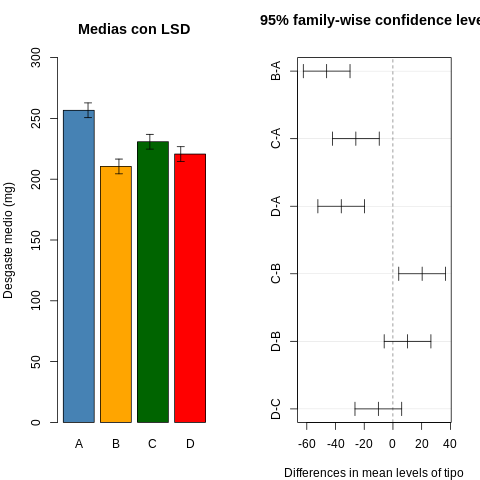

In [ ]:
%%R
# Instalar y cargar paquetes si no están ya instalados
if (!require(agricolae)) install.packages("agricolae", repos = "http://cran.us.r-project.org")
if (!require(multcomp)) install.packages("multcomp", repos = "http://cran.us.r-project.org")
library(agricolae)
library(multcomp)

# ============================================
# @title **B. COMPARACIONES MÚLTIPLES - EJEMPLO DE CUEROS**
# ============================================

# Datos
cuero_A <- c(264, 260, 258, 241, 262, 255)
cuero_B <- c(208, 220, 216, 200, 213, 206)
cuero_C <- c(220, 263, 219, 225, 230, 228)
cuero_D <- c(217, 226, 215, 224, 220, 222)

desgaste <- c(cuero_A, cuero_B, cuero_C, cuero_D)
tipo <- factor(rep(c("A", "B", "C", "D"), each = 6))
datos <- data.frame(desgaste, tipo)

# ANOVA
anova_modelo <- aov(desgaste ~ tipo, data = datos)

# Método LSD (manual)
n <- 6
k <- 4
N <- 24
CME <- summary(anova_modelo)[[1]]$`Mean Sq`[2]
gl_error <- summary(anova_modelo)[[1]]$Df[2]
t_critico <- qt(0.975, gl_error)
LSD <- t_critico * sqrt(2 * CME / n)
cat("LSD =", round(LSD, 3), "\n")

# Método de Tukey HSD
tukey_result <- TukeyHSD(anova_modelo, conf.level = 0.95)
print(tukey_result)

# Gráfico de Tukey
par(mfrow = c(1, 1)) # Reset plot layout for single plot
plot(tukey_result, las = 1, col = "steelblue")

# Método de Duncan
duncan_result <- duncan.test(anova_modelo, "tipo", alpha = 0.05, console = TRUE)

# Método de Dunnett (comparación con control, ejemplo con D como control)
# Reordenar niveles para que el control sea el primero
datos$tipo <- relevel(datos$tipo, ref = "D")
anova_control <- aov(desgaste ~ tipo, data = datos)
dunnett_result <- glht(anova_control, linfct = mcp(tipo = "Dunnett"))
summary(dunnett_result)
par(mfrow = c(1, 1)) # Reset plot layout for single plot
plot(dunnett_result)

# Gráfico de medias con LSD
medias <- tapply(desgaste, tipo, mean)
errores_lsd <- rep(LSD/2, 4)

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2)) # Set plot layout for two plots

# Gráfico de barras con LSD
barplot(medias, col = c("steelblue", "orange", "darkgreen", "red"),
        ylim = c(0, 300), ylab = "Desgaste medio (mg)",
        main = "Medias con LSD")
arrows(1:4, medias - errores_lsd, 1:4, medias + errores_lsd,
       angle = 90, code = 3, length = 0.05, col = "black")

# Gráfico de Tukey HSD
plot(tukey_result) # Removed 'main' argument to avoid conflict

=== TABLA ANOVA ===
               sum_sq    df          F    PR(>F)
C(tipo)   7072.333333   3.0  23.237501  0.000001
Residual  2029.000000  20.0        NaN       NaN

LSD = 58.475

=== TUKEY HSD ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B -46.1667    0.0 -62.4431 -29.8903   True
     A      C -25.8333 0.0013 -42.1097  -9.5569   True
     A      D    -36.0    0.0 -52.2764 -19.7236   True
     B      C  20.3333 0.0112   4.0569  36.6097   True
     B      D  10.1667 0.3263  -6.1097  26.4431  False
     C      D -10.1667 0.3263 -26.4431   6.1097  False
------------------------------------------------------


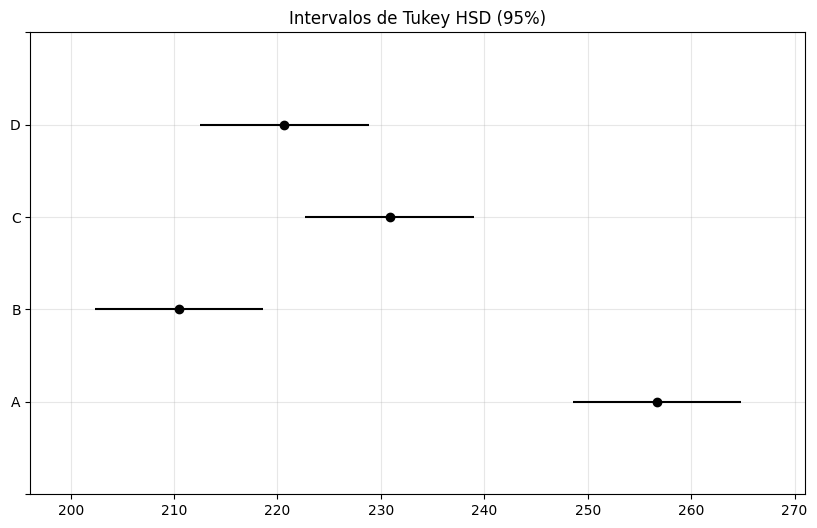

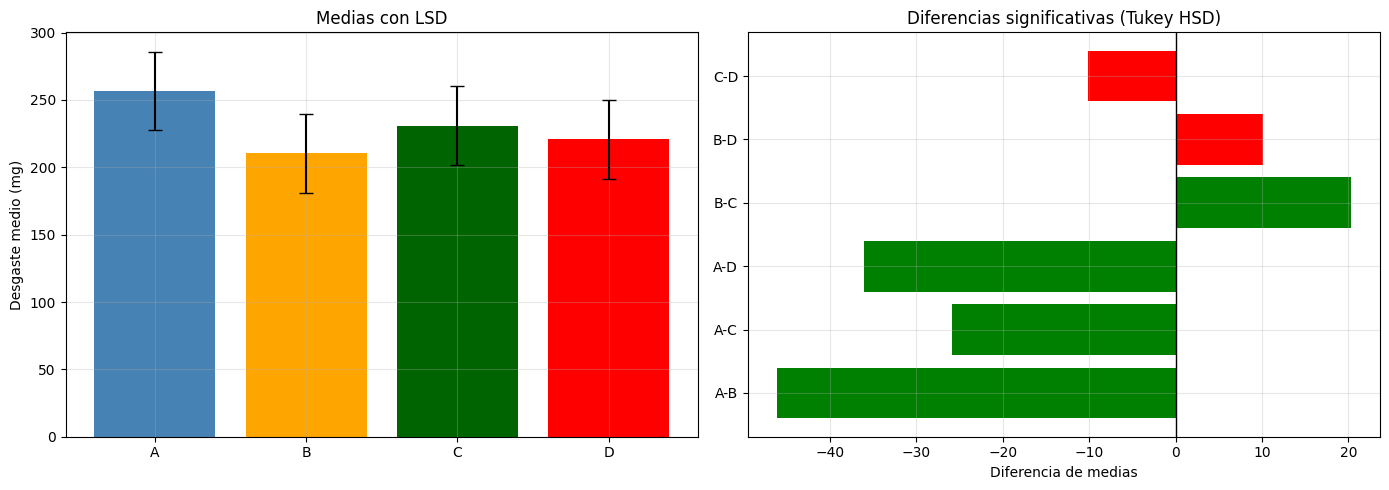


=== CONTRASTE ESPECÍFICO ===
H₀: 2μ_A - μ_B - μ_C = 0
Contraste estimado: 72.000
Varianza del contraste: 2357.444
Margen (Scheffé): 148.030
IC 95%: [-76.030, 220.030]
No rechazar H₀: el contraste no es significativamente diferente de cero


In [ ]:
# ============================================
# @title **C. COMPARACIONES MÚLTIPLES - EJEMPLO DE CUEROS**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f, t
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.libqsturng import psturng

# Datos
cuero_A = [264, 260, 258, 241, 262, 255]
cuero_B = [208, 220, 216, 200, 213, 206]
cuero_C = [220, 263, 219, 225, 230, 228]
cuero_D = [217, 226, 215, 224, 220, 222]

# Crear DataFrame
datos = pd.DataFrame({
    'desgaste': cuero_A + cuero_B + cuero_C + cuero_D,
    'tipo': ['A']*6 + ['B']*6 + ['C']*6 + ['D']*6
})

# ANOVA
modelo = ols('desgaste ~ C(tipo)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("=== TABLA ANOVA ===")
print(anova_table)

# Extraer valores
CME = anova_table.loc['C(tipo)', 'sum_sq'] / anova_table.loc['C(tipo)', 'df']
gl_error = anova_table.loc['Residual', 'df']

# Método LSD
n = 6
k = 4
N = 24
t_critico = t.ppf(0.975, gl_error)
LSD = t_critico * np.sqrt(2 * CME / n)
print(f"\nLSD = {LSD:.3f}")

# Método de Tukey HSD
tukey = pairwise_tukeyhsd(datos['desgaste'], datos['tipo'], alpha=0.05)
print("\n=== TUKEY HSD ===")
print(tukey)

# Gráfico de Tukey
tukey.plot_simultaneous()
plt.title('Intervalos de Tukey HSD (95%)')
plt.grid(True, alpha=0.3)

# Método LSD visual
medias = datos.groupby('tipo')['desgaste'].mean()
errores_lsd = [LSD/2] * 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras con LSD
axes[0].bar(medias.index, medias.values,
            color=['steelblue', 'orange', 'darkgreen', 'red'])
axes[0].errorbar(medias.index, medias.values, yerr=errores_lsd,
                 fmt='none', capsize=5, color='black')
axes[0].set_ylabel('Desgaste medio (mg)')
axes[0].set_title('Medias con LSD')
axes[0].grid(True, alpha=0.3)

# Gráfico de diferencias de Tukey
tukey_df = pd.DataFrame(tukey._results_table.data[1:],
                         columns=tukey._results_table.data[0])
colors = ['green' if x else 'red' for x in tukey_df['reject']]
axes[1].barh(range(len(tukey_df)), tukey_df['meandiff'], color=colors)
axes[1].axvline(0, color='black', linestyle='-', lw=1)
axes[1].set_yticks(range(len(tukey_df)))
axes[1].set_yticklabels(tukey_df['group1'] + '-' + tukey_df['group2'])
axes[1].set_xlabel('Diferencia de medias')
axes[1].set_title('Diferencias significativas (Tukey HSD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Contraste específico: 2μ_A - μ_B - μ_C
c = np.array([2, -1, -1, 0])
n_i = np.array([6, 6, 6, 6])
medias_arr = medias.values
C_hat = np.sum(c * medias_arr)
V_C = CME * np.sum(c**2 / n_i)
F_crit = f.ppf(0.95, k-1, gl_error)
margen = np.sqrt((k-1) * V_C * F_crit)

print(f"\n=== CONTRASTE ESPECÍFICO ===")
print(f"H₀: 2μ_A - μ_B - μ_C = 0")
print(f"Contraste estimado: {C_hat:.3f}")
print(f"Varianza del contraste: {V_C:.3f}")
print(f"Margen (Scheffé): {margen:.3f}")
print(f"IC 95%: [{C_hat - margen:.3f}, {C_hat + margen:.3f}]")
if C_hat - margen > 0 or C_hat + margen < 0:
    print("Rechazar H₀: el contraste es significativamente diferente de cero")
else:
    print("No rechazar H₀: el contraste no es significativamente diferente de cero")


[⬆️ Volver al inicio](#inicio4)

<a name="T33"></a>
## **33. EJEMPLO: RESISTENCIA A LA TENSIÓN - DCA - VERIFICACIÓN DE SUPUESTOS**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython



=== RESIDUOS POR TRATAMIENTO ===
15%: -2.8 -2.8 5.2 1.2 -0.8 
20%: -3.4 1.6 -3.4 2.6 2.6 
25%: -3.6 0.4 0.4 1.4 1.4 
30%: -2.6 3.4 0.4 -2.6 1.4 
35%: -3.8 -0.8 0.2 4.2 0.2 

=== PRUEBA DE SHAPIRO-WILK ===
Estadístico W: 0.9439 
Valor-p: 0.1818 
No se rechaza H₀: los residuos siguen una distribución normal.

=== PRUEBA DE BARTLETT ===
Estadístico χ²: 0.9331 
Valor-p: 0.9198 
No se rechaza H₀: las varianzas son homogéneas.

=== PRUEBA DE LEVENE ===
Estadístico F: 0.3179 
Valor-p: 0.8626 

=== PRUEBA DE DURBIN-WATSON ===
Estadístico DW: 2.4022 
Valor-p: 0.5808 
No hay evidencia de autocorrelación significativa.


Loading required package: car
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘RcppEigen’, ‘pbkrtest’, ‘lme4’

trying URL 'http://cran.us.r-project.org/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/pbkrtest_0.5.5.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/lme4_2.0-1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/car_3.1-5.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpTluFGl/downloaded_packages’
Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

Loading required package: lmtest
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package ca

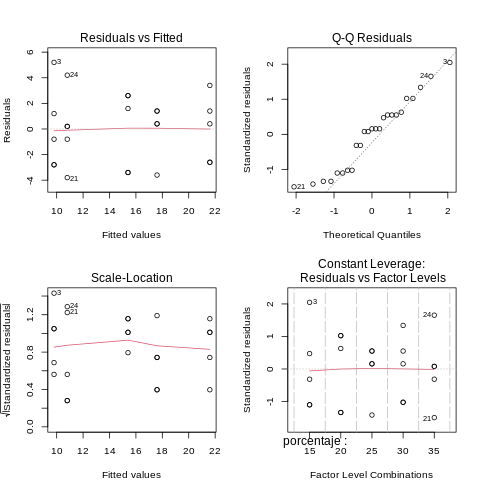

In [ ]:
%%R
# ============================================
# @title **B.  EJEMPLO: RESISTENCIA A LA TENSIÓN - DCA**
# VERIFICACIÓN DE SUPUESTOS
# ============================================
# Datos
porcentaje <- factor(rep(c(15, 20, 25, 30, 35), each = 5))
resistencia <- c(7, 7, 15, 11, 9,    # 15%
                 12, 17, 12, 18, 18,  # 20%
                 14, 18, 18, 19, 19,  # 25%
                 19, 25, 22, 19, 23,  # 30%
                 7, 10, 11, 15, 11)   # 35%

datos <- data.frame(porcentaje, resistencia)

# ANOVA
modelo <- aov(resistencia ~ porcentaje, data = datos)
summary(modelo)

# ============================================
# 1. CÁLCULO DE RESIDUOS
# ============================================
residuos <- residuals(modelo)
valores_ajustados <- fitted(modelo)

# Mostrar residuos por tratamiento
cat("\n=== RESIDUOS POR TRATAMIENTO ===\n")
residuos_por_trat <- split(residuos, porcentaje)
for (i in 1:5) {
  cat(paste0(names(residuos_por_trat)[i], "%:"),
      round(residuos_por_trat[[i]], 2), "\n")
}

# ============================================
# 2. VERIFICACIÓN DE NORMALIDAD
# ============================================
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

# Gráfica Q-Q de residuos
qqnorm(residuos, pch = 19, col = "steelblue",
       main = "Gráfica Q-Q de residuos")
qqline(residuos, col = "red", lwd = 2)

# Histograma de residuos
hist(residuos, breaks = 8, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Histograma de residuos", xlab = "Residuos")
curve(dnorm(x, mean(residuos), sd(residuos)), add = TRUE,
      col = "red", lwd = 2)

# Prueba de Shapiro-Wilk
shapiro_test <- shapiro.test(residuos)
cat("\n=== PRUEBA DE SHAPIRO-WILK ===\n")
cat("Estadístico W:", round(shapiro_test$statistic, 4), "\n")
cat("Valor-p:", round(shapiro_test$p.value, 4), "\n")
if (shapiro_test$p.value > 0.05) {
  cat("No se rechaza H₀: los residuos siguen una distribución normal.\n")
} else {
  cat("Se rechaza H₀: los residuos NO siguen una distribución normal.\n")
}

# ============================================
# 3. VERIFICACIÓN DE VARIANZA CONSTANTE
# ============================================

# Gráfica de residuos vs valores ajustados
plot(valores_ajustados, residuos, pch = 19, col = "steelblue",
     xlab = "Valores ajustados", ylab = "Residuos",
     main = "Residuos vs Valores ajustados")
abline(h = 0, col = "red", lty = 2, lwd = 2)

# Gráfica de residuos por tratamiento
boxplot(residuos ~ porcentaje, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red", "purple"),
        main = "Residuos por nivel de porcentaje",
        xlab = "Porcentaje de algodón", ylab = "Residuos")
abline(h = 0, col = "red", lty = 2, lwd = 2)

# Prueba de Bartlett
bartlett_test <- bartlett.test(resistencia ~ porcentaje, data = datos)
cat("\n=== PRUEBA DE BARTLETT ===\n")
cat("Estadístico χ²:", round(bartlett_test$statistic, 4), "\n")
cat("Valor-p:", round(bartlett_test$p.value, 4), "\n")
if (bartlett_test$p.value > 0.05) {
  cat("No se rechaza H₀: las varianzas son homogéneas.\n")
} else {
  cat("Se rechaza H₀: las varianzas NO son homogéneas.\n")
}

# Prueba de Levene
if (!require(car)) install.packages("car", repos = "http://cran.us.r-project.org")
library(car)
levene_test <- leveneTest(resistencia ~ porcentaje, data = datos)
cat("\n=== PRUEBA DE LEVENE ===\n")
cat("Estadístico F:", round(levene_test$`F value`[1], 4), "\n")
cat("Valor-p:", round(levene_test$`Pr(>F)`[1], 4), "\n")

# ============================================
# 4. VERIFICACIÓN DE INDEPENDENCIA
# ============================================

# Gráfica de residuos en secuencia temporal
plot(1:25, residuos, type = "b", pch = 19, col = "steelblue",
     xlab = "Orden de ejecución", ylab = "Residuos",
     main = "Residuos en secuencia temporal")
abline(h = 0, col = "red", lty = 2, lwd = 2)

# Prueba de Durbin-Watson para autocorrelación
if (!require(lmtest)) install.packages("lmtest", repos = "http://cran.us.r-project.org")
library(lmtest)
dw_test <- dwtest(modelo)
cat("\n=== PRUEBA DE DURBIN-WATSON ===\n")
cat("Estadístico DW:", round(dw_test$statistic, 4), "\n")
cat("Valor-p:", round(dw_test$p.value, 4), "\n")
if (dw_test$p.value > 0.05) {
  cat("No hay evidencia de autocorrelación significativa.\n")
} else {
  cat("Hay evidencia de autocorrelación significativa.\n")
}

# ============================================
# 5. GRÁFICAS COMPLETAS DE DIAGNÓSTICO
# ============================================
par(mfrow = c(2, 2))
plot(modelo)

=== TABLA ANOVA ===
               sum_sq    df          F    PR(>F)
C(porcentaje)  475.76   4.0  14.756824  0.000009
Residual       161.20  20.0        NaN       NaN

=== RESIDUOS POR TRATAMIENTO ===
15%: 0   -2.8
1   -2.8
2    5.2
3    1.2
4   -0.8
dtype: float64
20%: 5   -3.4
6    1.6
7   -3.4
8    2.6
9    2.6
dtype: float64
25%: 10   -3.6
11    0.4
12    0.4
13    1.4
14    1.4
dtype: float64
30%: 15   -2.6
16    3.4
17    0.4
18   -2.6
19    1.4
dtype: float64
35%: 20   -3.8
21   -0.8
22    0.2
23    4.2
24    0.2
dtype: float64

=== PRUEBA DE SHAPIRO-WILK ===
Estadístico W: 0.9439
Valor-p: 0.1818
No se rechaza H₀: los residuos siguen una distribución normal.


/tmp/ipykernel_55703/2768921592.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(datos_plot,


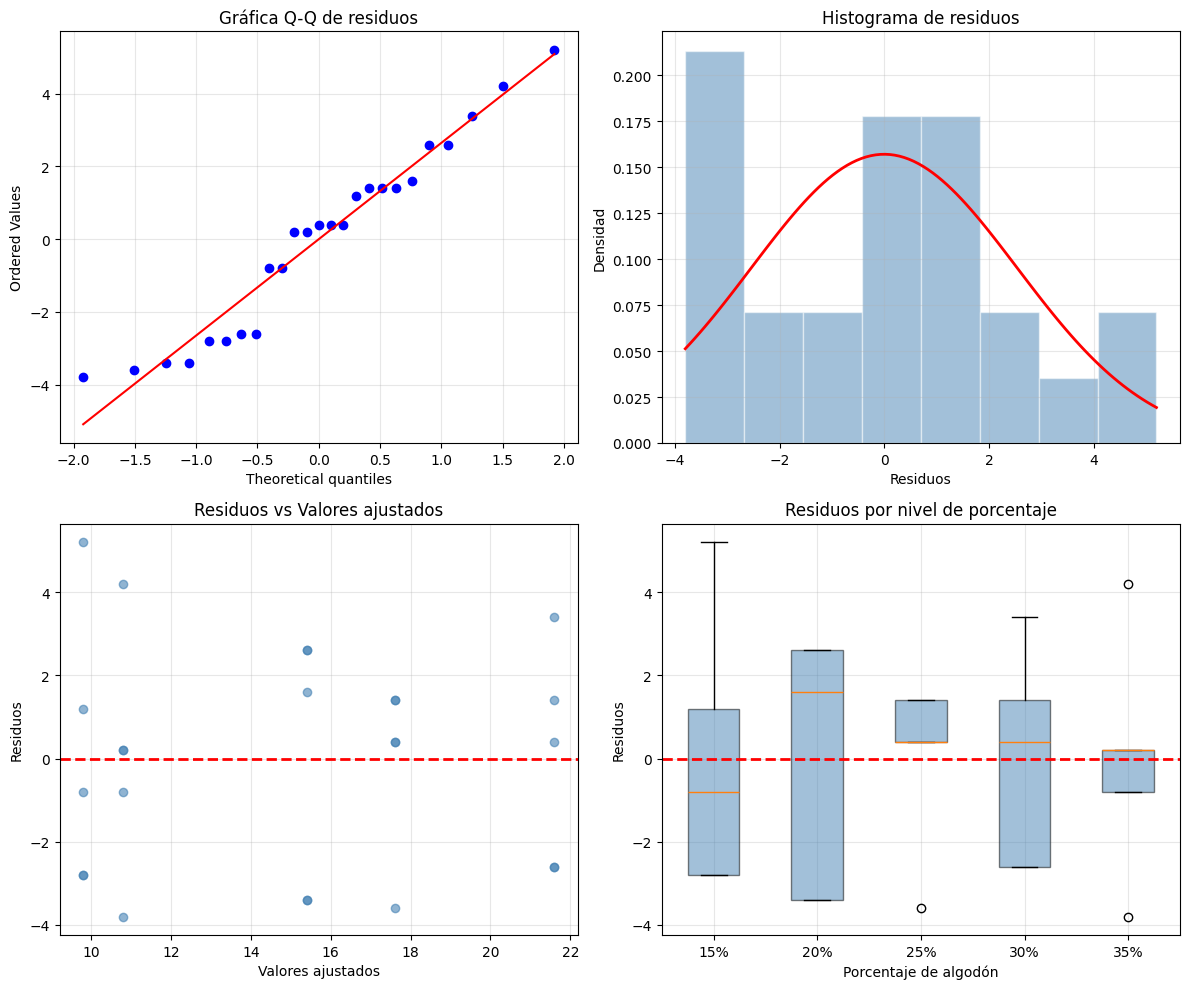


=== PRUEBA DE BARTLETT ===
Estadístico χ²: 3.1486
Valor-p: 0.5333
No se rechaza H₀: las varianzas son homogéneas.

=== PRUEBA DE LEVENE ===
Estadístico F: 0.3179
Valor-p: 0.8626


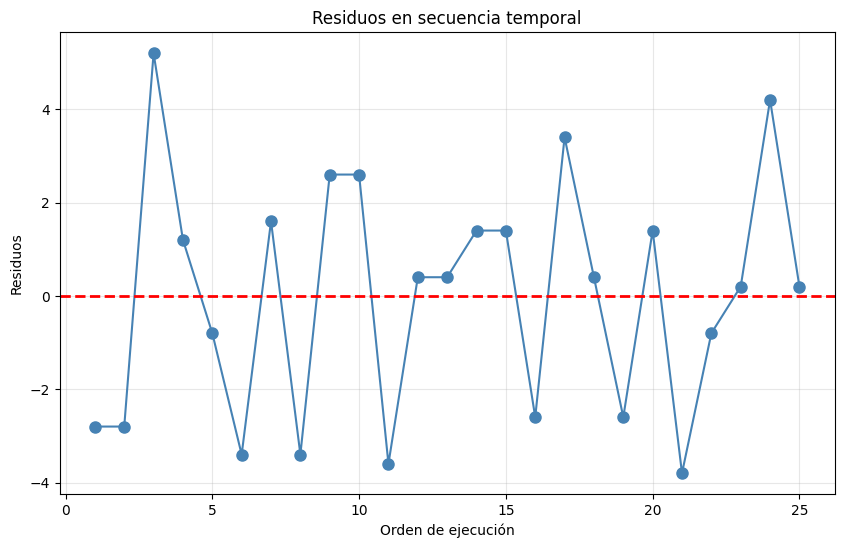


=== PRUEBA DE DURBIN-WATSON ===
Estadístico DW: 2.4022
No hay evidencia de autocorrelación significativa.


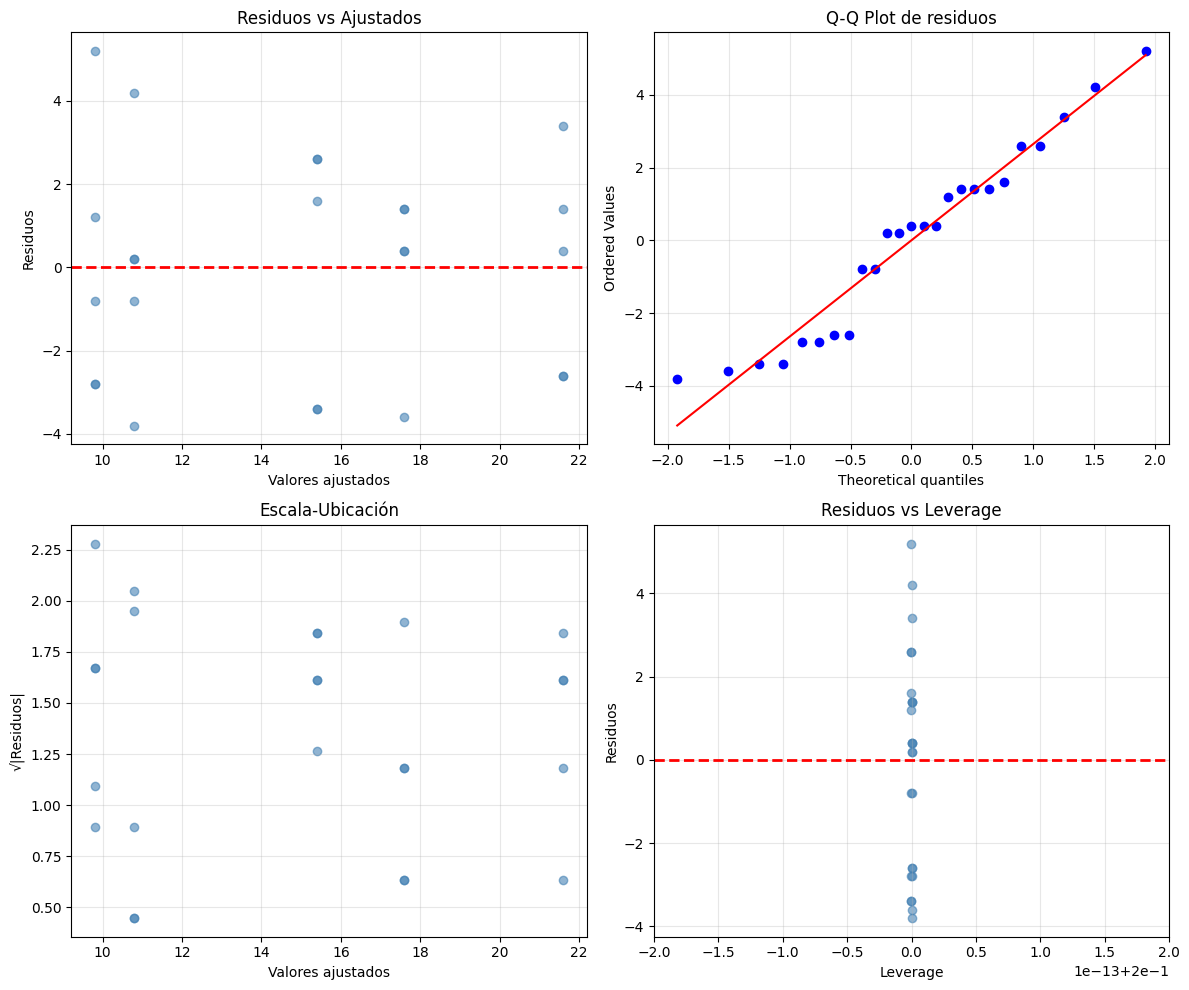

In [ ]:
# ============================================
# @title **C. EJEMPLO: RESISTENCIA A LA TENSIÓN - DCA**
# VERIFICACIÓN DE SUPUESTOS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import bartlett, levene, shapiro

# Datos
porcentaje = [15]*5 + [20]*5 + [25]*5 + [30]*5 + [35]*5
resistencia = [7, 7, 15, 11, 9,    # 15%
               12, 17, 12, 18, 18,  # 20%
               14, 18, 18, 19, 19,  # 25%
               19, 25, 22, 19, 23,  # 30%
               7, 10, 11, 15, 11]   # 35%

datos = pd.DataFrame({'porcentaje': porcentaje, 'resistencia': resistencia})
datos['porcentaje'] = datos['porcentaje'].astype('category')

# ANOVA
modelo = ols('resistencia ~ C(porcentaje)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("=== TABLA ANOVA ===")
print(anova_table)

# ============================================
# 1. CÁLCULO DE RESIDUOS
# ============================================
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

print("\n=== RESIDUOS POR TRATAMIENTO ===")
for p in datos['porcentaje'].cat.categories:
    mask = datos['porcentaje'] == p
    residuos_trat = residuos[mask]
    print(f"{p}%: {np.round(residuos_trat, 2)}")

# ============================================
# 2. VERIFICACIÓN DE NORMALIDAD
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfica Q-Q de residuos
stats.probplot(residuos, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Gráfica Q-Q de residuos")
axes[0, 0].grid(True, alpha=0.3)

# Histograma de residuos
axes[0, 1].hist(residuos, bins=8, density=True, alpha=0.5,
                color='steelblue', edgecolor='white')
x = np.linspace(min(residuos), max(residuos), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, np.mean(residuos), np.std(residuos)),
                'r-', lw=2)
axes[0, 1].set_title("Histograma de residuos")
axes[0, 1].set_xlabel("Residuos")
axes[0, 1].set_ylabel("Densidad")
axes[0, 1].grid(True, alpha=0.3)

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuos)
print("\n=== PRUEBA DE SHAPIRO-WILK ===")
print(f"Estadístico W: {shapiro_stat:.4f}")
print(f"Valor-p: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("No se rechaza H₀: los residuos siguen una distribución normal.")
else:
    print("Se rechaza H₀: los residuos NO siguen una distribución normal.")

# ============================================
# 3. VERIFICACIÓN DE VARIANZA CONSTANTE
# ============================================

# Gráfica de residuos vs valores ajustados
axes[1, 0].scatter(valores_ajustados, residuos, alpha=0.6, color='steelblue')
axes[1, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 0].set_xlabel("Valores ajustados")
axes[1, 0].set_ylabel("Residuos")
axes[1, 0].set_title("Residuos vs Valores ajustados")
axes[1, 0].grid(True, alpha=0.3)

# Gráfica de residuos por tratamiento
datos_plot = [residuos[datos['porcentaje'] == p]
              for p in datos['porcentaje'].cat.categories]
bp = axes[1, 1].boxplot(datos_plot,
                         labels=[f"{p}%" for p in datos['porcentaje'].cat.categories],
                         patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.5)
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_xlabel("Porcentaje de algodón")
axes[1, 1].set_ylabel("Residuos")
axes[1, 1].set_title("Residuos por nivel de porcentaje")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prueba de Bartlett
grupos = [resistencia[i*5:(i+1)*5] for i in range(5)]
bartlett_stat, bartlett_p = bartlett(*grupos)
print("\n=== PRUEBA DE BARTLETT ===")
print(f"Estadístico χ²: {bartlett_stat:.4f}")
print(f"Valor-p: {bartlett_p:.4f}")
if bartlett_p > 0.05:
    print("No se rechaza H₀: las varianzas son homogéneas.")
else:
    print("Se rechaza H₀: las varianzas NO son homogéneas.")

# Prueba de Levene
levene_stat, levene_p = levene(*grupos)
print("\n=== PRUEBA DE LEVENE ===")
print(f"Estadístico F: {levene_stat:.4f}")
print(f"Valor-p: {levene_p:.4f}")

# ============================================
# 4. VERIFICACIÓN DE INDEPENDENCIA
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 26), residuos, 'o-', color='steelblue', markersize=8)
ax.axhline(y=0, color='red', linestyle='--', lw=2)
ax.set_xlabel("Orden de ejecución")
ax.set_ylabel("Residuos")
ax.set_title("Residuos en secuencia temporal")
ax.grid(True, alpha=0.3)
plt.show()

# Prueba de Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuos)
print("\n=== PRUEBA DE DURBIN-WATSON ===")
print(f"Estadístico DW: {dw:.4f}")
if dw > 1.5 and dw < 2.5:
    print("No hay evidencia de autocorrelación significativa.")
else:
    print("Hay posible evidencia de autocorrelación.")

# ============================================
# 5. GRÁFICAS DE DIAGNÓSTICO (similar a plot(modelo) en R)
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuos vs ajustados
axes[0, 0].scatter(valores_ajustados, residuos, alpha=0.6, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel("Valores ajustados")
axes[0, 0].set_ylabel("Residuos")
axes[0, 0].set_title("Residuos vs Ajustados")
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot de residuos")
axes[0, 1].grid(True, alpha=0.3)

# Escala-ubicación
sqrt_abs_resid = np.sqrt(np.abs(residuos))
axes[1, 0].scatter(valores_ajustados, sqrt_abs_resid, alpha=0.6, color='steelblue')
axes[1, 0].set_xlabel("Valores ajustados")
axes[1, 0].set_ylabel("√|Residuos|")
axes[1, 0].set_title("Escala-Ubicación")
axes[1, 0].grid(True, alpha=0.3)

# Residuos vs leverage
from statsmodels.stats.outliers_influence import OLSInfluence
influence = OLSInfluence(modelo)
leverage = influence.hat_matrix_diag
axes[1, 1].scatter(leverage, residuos, alpha=0.6, color='steelblue')
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Residuos")
axes[1, 1].set_title("Residuos vs Leverage")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio4)

<a name="T34"></a>
## **34. PRUEBA DE SHAPIRO-WILK**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== PRUEBA DE SHAPIRO-WILK ===
Estadístico W: 0.943868 
Valor-p: 0.181758 

No se rechaza H₀: los datos siguen una distribución normal.


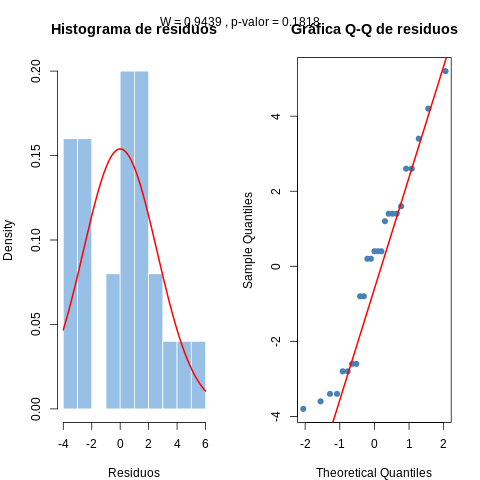

In [ ]:
%%R
# ============================================
# @title **B. PRUEBA DE SHAPIRO-WILK EN R**
# ============================================

# Datos de los residuos del ejemplo
residuos <- c(-3.8, -3.6, -3.4, -3.4, -2.8, -2.8, -2.6, -2.6, -0.8, -0.8,
              0.2, 0.2, 0.4, 0.4, 0.4, 1.2, 1.4, 1.4, 1.4, 1.6,
              2.6, 2.6, 3.4, 4.2, 5.2)

# Prueba de Shapiro-Wilk
shapiro_test <- shapiro.test(residuos)

cat("=== PRUEBA DE SHAPIRO-WILK ===\n")
cat("Estadístico W:", round(shapiro_test$statistic, 6), "\n")
cat("Valor-p:", round(shapiro_test$p.value, 6), "\n\n")

if (shapiro_test$p.value > 0.05) {
  cat("No se rechaza H₀: los datos siguen una distribución normal.\n")
} else {
  cat("Se rechaza H₀: los datos NO siguen una distribución normal.\n")
}

# Visualización
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histograma con curva normal
hist(residuos, breaks = 8, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Histograma de residuos", xlab = "Residuos")
curve(dnorm(x, mean(residuos), sd(residuos)), add = TRUE,
      col = "red", lwd = 2)

# Q-Q plot
qqnorm(residuos, pch = 19, col = "steelblue",
       main = "Gráfica Q-Q de residuos")
qqline(residuos, col = "red", lwd = 2)

# Agregar texto con resultados
mtext(paste("W =", round(shapiro_test$statistic, 4),
            ", p-valor =", round(shapiro_test$p.value, 4)),
      side = 3, line = -2, outer = TRUE)





=== PRUEBA DE SHAPIRO-WILK ===
Estadístico W: 0.943868
Valor-p: 0.181758

No se rechaza H₀: los datos siguen una distribución normal.


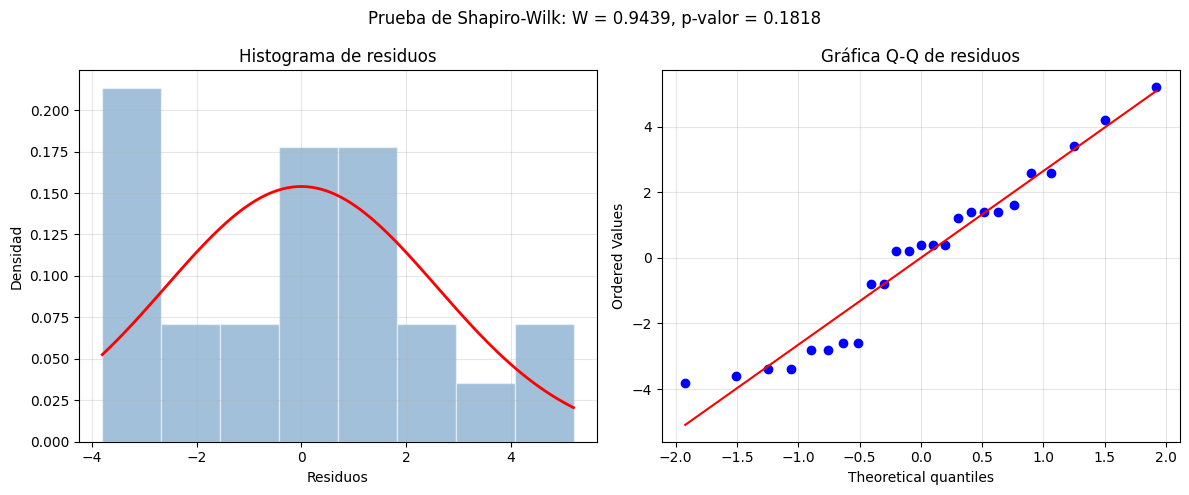

In [ ]:
# ============================================
# @title **C.  PRUEBA DE SHAPIRO-WILK EN PYTHON**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Datos de los residuos del ejemplo
residuos = np.array([-3.8, -3.6, -3.4, -3.4, -2.8, -2.8, -2.6, -2.6, -0.8, -0.8,
                     0.2, 0.2, 0.4, 0.4, 0.4, 1.2, 1.4, 1.4, 1.4, 1.6,
                     2.6, 2.6, 3.4, 4.2, 5.2])

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)

print("=== PRUEBA DE SHAPIRO-WILK ===")
print(f"Estadístico W: {shapiro_stat:.6f}")
print(f"Valor-p: {shapiro_p:.6f}\n")

if shapiro_p > 0.05:
    print("No se rechaza H₀: los datos siguen una distribución normal.")
else:
    print("Se rechaza H₀: los datos NO siguen una distribución normal.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma con curva normal
axes[0].hist(residuos, bins=8, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')
x = np.linspace(min(residuos), max(residuos), 100)
axes[0].plot(x, stats.norm.pdf(x, np.mean(residuos), np.std(residuos, ddof=1)),
             'r-', lw=2)
axes[0].set_xlabel("Residuos")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Histograma de residuos")
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Gráfica Q-Q de residuos")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Prueba de Shapiro-Wilk: W = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")
plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio4)

<a name="T35"></a>
## **35. EJEMPLO: MODELO DE EFECTOS ALEATORIOS DURACIÓN DE PRÉSTAMOS HIPOTECARIOS**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[1] "Estadísticos descriptivos:"
# A tibble: 5 × 5
  empleado     n media    sd   var
  <fct>    <int> <dbl> <dbl> <dbl>
1 1            9  243.  68.9  4744
2 2            9  287.  78.1  6100
3 3            9  317.  45.3  2050
4 4            9  327.  43.6  1900
5 5            9  333.  43.6  1900

=== COMPONENTES DE VARIANZA ===
CMTr = 12504.8 
CME = 3338.8 
σ² estimada = 3338.8 
σ_A² estimada = 1018.44 


Loading required package: Matrix
Registered S3 method overwritten by 'lme4':
  method           from
  na.action.merMod car 


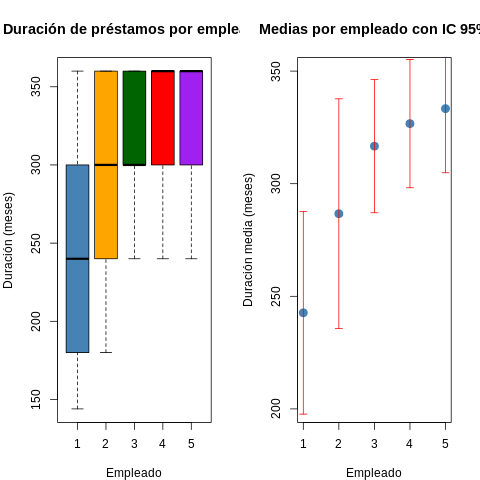

In [ ]:


# ============================================
# @title **B. EJEMPLO: MODELO DE EFECTOS ALEATORIOS**
# DURACIÓN DE PRÉSTAMOS HIPOTECARIOS
# ============================================
%%R

# Datos
empleado1 <- c(180, 240, 300, 360, 240, 180, 144, 300, 240)
empleado2 <- c(240, 360, 180, 180, 300, 240, 360, 360, 360)
empleado3 <- c(240, 270, 300, 360, 360, 300, 360, 360, 300)
empleado4 <- c(300, 240, 300, 360, 360, 360, 360, 360, 300)
empleado5 <- c(300, 360, 240, 360, 360, 360, 360, 300, 360)

# Crear data frame
duracion <- c(empleado1, empleado2, empleado3, empleado4, empleado5)
empleado <- factor(rep(1:5, each = 9))
datos <- data.frame(duracion, empleado)

# Estadísticos descriptivos
library(dplyr)
resumen <- datos %>%
  group_by(empleado) %>%
  summarise(
    n = n(),
    media = mean(duracion),
    sd = sd(duracion),
    var = var(duracion)
  )
print("Estadísticos descriptivos:")
print(resumen)

# ANOVA (Modelo de efectos aleatorios)
# En R, se especifica con Error() o usando lme4
modelo_fijo <- aov(duracion ~ empleado, data = datos)
summary(modelo_fijo)

# Para efectos aleatorios, usamos lme4
library(lme4)
modelo_aleatorio <- lmer(duracion ~ 1 + (1 | empleado), data = datos)
summary(modelo_aleatorio)

# Extraer componentes de varianza
VarCorr(modelo_aleatorio)

# Cálculo manual de componentes de varianza
SCTr <- sum((resumen$media - mean(datos$duracion))^2 * resumen$n)
SCE <- sum((resumen$n - 1) * resumen$var)
CMTr <- SCTr / (5 - 1)
CME <- SCE / (45 - 5)

cat("\n=== COMPONENTES DE VARIANZA ===\n")
cat("CMTr =", round(CMTr, 2), "\n")
cat("CME =", round(CME, 2), "\n")
cat("σ² estimada =", round(CME, 2), "\n")
cat("σ_A² estimada =", round((CMTr - CME) / 9, 2), "\n")

# Gráficos
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Boxplot por empleado
boxplot(duracion ~ empleado, data = datos,
        col = c("steelblue", "orange", "darkgreen", "red", "purple"),
        main = "Duración de préstamos por empleado",
        xlab = "Empleado", ylab = "Duración (meses)")

# Gráfico de medias con intervalos de confianza
medias <- resumen$media
errores <- resumen$sd / sqrt(resumen$n)
plot(1:5, medias, pch = 19, col = "steelblue", cex = 1.5,
     xlab = "Empleado", ylab = "Duración media (meses)",
     xaxt = "n", ylim = c(200, 350),
     main = "Medias por empleado con IC 95%")
axis(1, at = 1:5, labels = 1:5)
arrows(1:5, medias - 1.96*errores, 1:5, medias + 1.96*errores,
       angle = 90, code = 3, length = 0.05, col = "red")





=== ESTADÍSTICOS DESCRIPTIVOS ===
          count        mean        std     var
empleado                                      
1             9  242.666667  68.876701  4744.0
2             9  286.666667  78.102497  6100.0
3             9  316.666667  45.276926  2050.0
4             9  326.666667  43.588989  1900.0
5             9  333.333333  43.588989  1900.0

=== TABLA ANOVA (EFECTOS FIJOS) ===
               sum_sq    df         F    PR(>F)
C(empleado)   50019.2   4.0  3.745298  0.011129
Residual     133552.0  40.0       NaN       NaN

=== COMPONENTES DE VARIANZA ===
CMTr = 12504.80
CME = 3338.80
σ² estimada = 3338.80
σ_A² estimada = 1018.44

=== PRUEBA DE HIPÓTESIS ===
F₀ = 3.7453
Valor crítico F(0.95, 4, 40) = 2.6060
Valor-p = 0.011129
Se rechaza H₀: existe variabilidad significativa entre empleados.


/tmp/ipykernel_55703/990246494.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('empleado')['duracion'].agg(['count', 'mean', 'std', 'var']))
/tmp/ipykernel_55703/990246494.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = datos.groupby('empleado')['duracion'].agg(['mean', 'var', 'count']).reset_index()


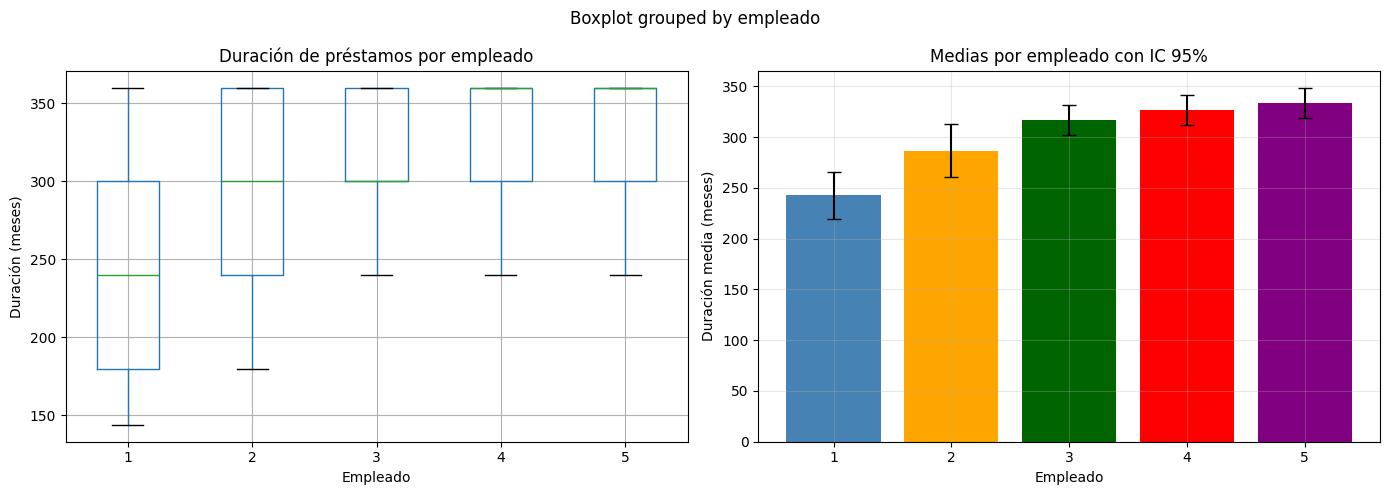

In [ ]:
# ============================================
# @title **C. EJEMPLO: MODELO DE EFECTOS ALEATORIOS**
# DURACIÓN DE PRÉSTAMOS HIPOTECARIOS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols, mixedlm
from scipy.stats import f

# Datos
empleado1 = [180, 240, 300, 360, 240, 180, 144, 300, 240]
empleado2 = [240, 360, 180, 180, 300, 240, 360, 360, 360]
empleado3 = [240, 270, 300, 360, 360, 300, 360, 360, 300]
empleado4 = [300, 240, 300, 360, 360, 360, 360, 360, 300]
empleado5 = [300, 360, 240, 360, 360, 360, 360, 300, 360]

# Crear DataFrame
datos = pd.DataFrame({
    'duracion': empleado1 + empleado2 + empleado3 + empleado4 + empleado5,
    'empleado': ['1']*9 + ['2']*9 + ['3']*9 + ['4']*9 + ['5']*9
})
datos['empleado'] = datos['empleado'].astype('category')

# Estadísticos descriptivos
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(datos.groupby('empleado')['duracion'].agg(['count', 'mean', 'std', 'var']))

# ANOVA (Modelo de efectos fijos)
modelo_fijo = ols('duracion ~ C(empleado)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo_fijo, typ=2)
print("\n=== TABLA ANOVA (EFECTOS FIJOS) ===")
print(anova_table)

# Cálculo manual de componentes de varianza
resumen = datos.groupby('empleado')['duracion'].agg(['mean', 'var', 'count']).reset_index()
resumen.columns = ['empleado', 'media', 'var', 'n']

media_total = datos['duracion'].mean()
N = len(datos)
k = len(resumen)

SCTr = sum(resumen['n'] * (resumen['media'] - media_total)**2)
SCE = sum((resumen['n'] - 1) * resumen['var'])
CMTr = SCTr / (k - 1)
CME = SCE / (N - k)

print("\n=== COMPONENTES DE VARIANZA ===")
print(f"CMTr = {CMTr:.2f}")
print(f"CME = {CME:.2f}")
print(f"σ² estimada = {CME:.2f}")
print(f"σ_A² estimada = {(CMTr - CME) / 9:.2f}")

# Prueba F
F_stat = CMTr / CME
F_crit = f.ppf(0.95, k-1, N-k)
p_valor = 1 - f.cdf(F_stat, k-1, N-k)

print(f"\n=== PRUEBA DE HIPÓTESIS ===")
print(f"F₀ = {F_stat:.4f}")
print(f"Valor crítico F(0.95, {k-1}, {N-k}) = {F_crit:.4f}")
print(f"Valor-p = {p_valor:.6f}")

if F_stat > F_crit:
    print("Se rechaza H₀: existe variabilidad significativa entre empleados.")
else:
    print("No se rechaza H₀: no hay evidencia de variabilidad entre empleados.")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por empleado
datos.boxplot(column='duracion', by='empleado', ax=axes[0])
axes[0].set_title('Duración de préstamos por empleado')
axes[0].set_xlabel('Empleado')
axes[0].set_ylabel('Duración (meses)')

# Gráfico de medias
medias = resumen['media']
errores = np.sqrt(resumen['var'] / resumen['n'])
axes[1].bar(range(1, 6), medias, yerr=errores, capsize=5,
            color=['steelblue', 'orange', 'darkgreen', 'red', 'purple'])
axes[1].set_xlabel('Empleado')
axes[1].set_ylabel('Duración media (meses)')
axes[1].set_title('Medias por empleado con IC 95%')
axes[1].set_xticks(range(1, 6))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio4)